# Feature Selection

Goal:
Clean the feature space before training models to reduce noisy data

Strategy:
1. Variance filtering (remove near-constant features)
2. Correlation filtering (remove highly redundant features)
3. SHAP-based selection 


- All decisions are based on training set only
- Same selected features will be applied to validation and test sets

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from lightgbm import LGBMClassifier
from utils import run_shap_analysis
import shap

/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# we selected  Datset B features (position-specific feature for peptides + global features for HLA seqs)
# after testing two other versions of datasets (one with only global features and one with only position-specific features for peptides) and found that this version performs best on the validation set
# we decided to further clean the feature space for better results

train = pd.read_csv("../data/dataset_B_train.csv")
val = pd.read_csv("../data/dataset_B_val.csv")
test = pd.read_csv("../data/dataset_B_test.csv")
print("Before cleaning:")
print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

Before cleaning:
Train shape: (5707, 295)
Val shape: (1446, 295)
Test shape: (1815, 295)


In [3]:
# seperate the metadata columns from the feature columns
metadata_cols = ["index", "peptide", "HLA", "hla_sequence", "Label"]

X_train = train.drop(columns=metadata_cols)
y_train = train["Label"]

X_val = val.drop(columns=metadata_cols)
y_val = val["Label"]

X_test = test.drop(columns=metadata_cols)
y_test = test["Label"]

print("Number of features:", X_train.shape[1])

Number of features: 290


## Step 1: Variance Filtering

Remove features with very low variance (almost constant).

with a safe threshold of 0.01

In [4]:
selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train)

selected_var_features = X_train.columns[selector.get_support()]
removed_var_features = X_train.columns[~selector.get_support()]

print("Before:", X_train.shape[1])
print("Dropped:", len(removed_var_features))
print("After variance filter:", len(selected_var_features))

print(list(removed_var_features))

X_train = X_train[selected_var_features]

Before: 290
Dropped: 77
After variance filter: 213
['PeptidePos_p1_f4', 'PeptidePos_p1_f12', 'PeptidePos_p2_f4', 'PeptidePos_p2_f12', 'PeptidePos_p3_f4', 'PeptidePos_p3_f12', 'PeptidePos_p4_f4', 'PeptidePos_p4_f12', 'PeptidePos_p5_f4', 'PeptidePos_p5_f12', 'PeptidePos_p6_f4', 'PeptidePos_p6_f12', 'PeptidePos_p7_f4', 'PeptidePos_p7_f12', 'PeptidePos_p8_f4', 'PeptidePos_p8_f12', 'PeptidePos_p9_f4', 'PeptidePos_p9_f12', 'HLA_AF4', 'HLA_BLOSUM2', 'HLA_BLOSUM3', 'HLA_BLOSUM4', 'HLA_BLOSUM5', 'HLA_BLOSUM6', 'HLA_BLOSUM7', 'HLA_BLOSUM8', 'HLA_BLOSUM9', 'HLA_BLOSUM10', 'HLA_PP2', 'HLA_PP3', 'HLA_F1', 'HLA_F2', 'HLA_F3', 'HLA_F4', 'HLA_F5', 'HLA_KF2', 'HLA_KF6', 'HLA_KF7', 'HLA_KF8', 'HLA_KF9', 'HLA_MSWHIM1', 'HLA_MSWHIM2', 'HLA_MSWHIM3', 'HLA_E1', 'HLA_E2', 'HLA_E3', 'HLA_E4', 'HLA_E5', 'HLA_ProtFP8', 'HLA_SV1', 'HLA_SV2', 'HLA_SV3', 'HLA_SV4', 'HLA_ST1', 'HLA_ST2', 'HLA_ST3', 'HLA_ST4', 'HLA_ST5', 'HLA_ST6', 'HLA_ST7', 'HLA_ST8', 'HLA_SVGER6', 'HLA_SVGER9', 'HLA_T4', 'HLA_T5', 'HLA_VHSE3', 'H

## Step 2: Correlation Filtering

Remove highly correlated features (threshold = 0.95).


In [5]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print("Before:", X_train.shape[1])
print("Dropped:", len(to_drop))
print("After correlation filter:", X_train.shape[1] - len(to_drop))

print(list(to_drop))


X_train = X_train.drop(columns=to_drop)

Before: 213
Dropped: 44
After correlation filter: 169
['PeptidePos_p1_f6', 'PeptidePos_p2_f6', 'PeptidePos_p3_f6', 'PeptidePos_p4_f6', 'PeptidePos_p5_f6', 'PeptidePos_p6_f6', 'PeptidePos_p7_f6', 'PeptidePos_p8_f6', 'PeptidePos_p9_f6', 'PeptidePos_p10_f4', 'PeptidePos_p10_f5', 'PeptidePos_p10_f6', 'PeptidePos_p10_f7', 'PeptidePos_p10_f8', 'PeptidePos_p10_f9', 'PeptidePos_p10_f10', 'PeptidePos_p10_f11', 'PeptidePos_p10_f12', 'PeptidePos_p10_f13', 'PeptidePos_p10_f14', 'PeptidePos_p10_f15', 'PeptidePos_p10_f16', 'PeptidePos_p10_f17', 'PeptidePos_p10_f18', 'HLA_PP1', 'HLA_KF1', 'HLA_KF4', 'HLA_PD2', 'HLA_PRIN1', 'HLA_ProtFP1', 'HLA_ProtFP7', 'HLA_SVGER7', 'HLA_SVGER8', 'HLA_SVGER10', 'HLA_T1', 'HLA_VHSE1', 'HLA_VHSE2', 'HLA_Z1', 'HLA_Z2', 'HLA_Z4', 'HLA_boman', 'HLA_hydrophobicity', 'HLA_molecular_weight', 'HLA_mz']


## Step 3: SHAP-based Feature Selection

After removing near-constant and highly correlated features, the next step is to use SHAP values to measure feature importance.

- SHAP is computed on the training set only


In [6]:
model_fs = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model_fs.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2564, number of negative: 3143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 5707, number of used features: 169
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.449273 -> initscore=-0.203609
[LightGBM] [Info] Start training from score -0.203609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


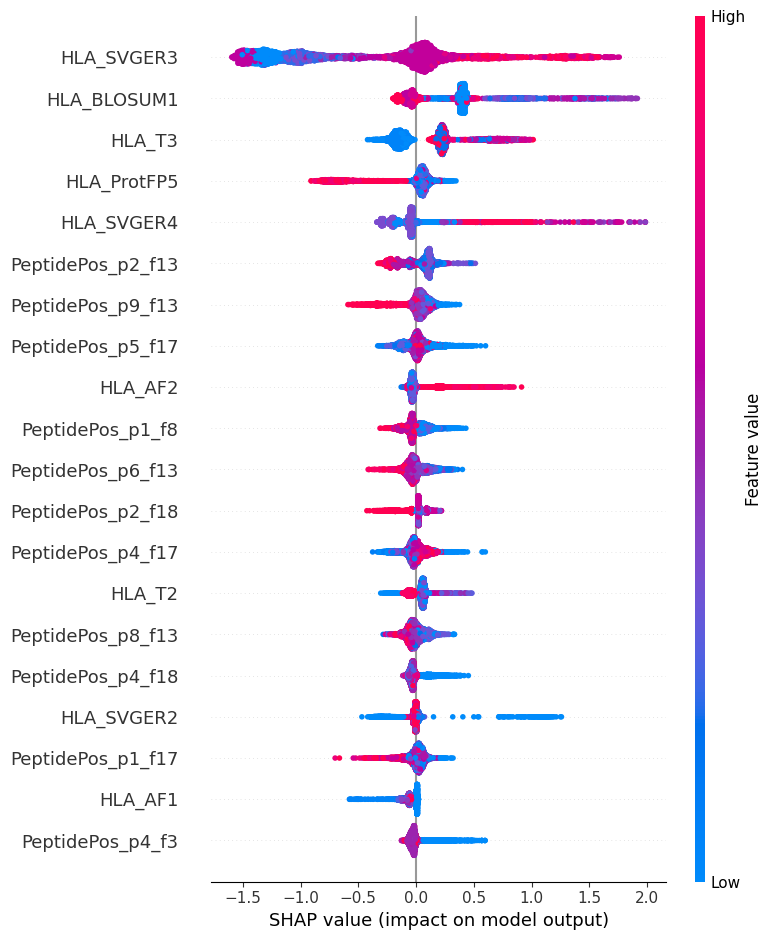

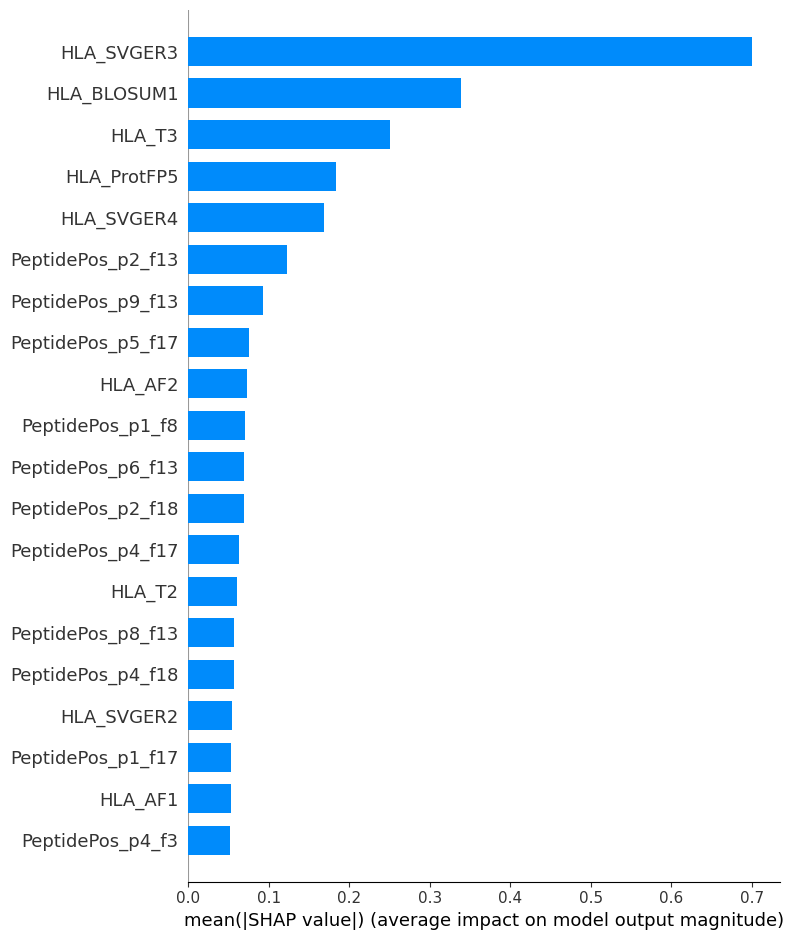

In [7]:
run_shap_analysis(model_fs, X_train, max_display=20)

In [8]:
explainer = shap.TreeExplainer(model_fs)
shap_values = explainer.shap_values(X_train)

# handle binary classification output
if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_shap = np.abs(shap_values).mean(axis=0)

/home/hamdaalhosani/Downloads/yes/envs/benchmark/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [9]:
# importance table
shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": mean_shap
}).sort_values(by="importance", ascending=False)

print("Before SHAP filter:", X_train.shape[1])
shap_importance.head(20)

Before SHAP filter: 169


,feature,importance
157,HLA_SVGER3,0.699953
142,HLA_BLOSUM1,0.338378
162,HLA_T3,0.250651
153,HLA_ProtFP5,0.183864
158,HLA_SVGER4,0.168525
24,PeptidePos_p2_f13,0.122453
129,PeptidePos_p9_f13,0.093281
73,PeptidePos_p5_f17,0.074961
139,HLA_AF2,0.073502
5,PeptidePos_p1_f8,0.070331


In [10]:
threshold = np.percentile(mean_shap, 10)

selected_shap_features = shap_importance[
    shap_importance["importance"] > threshold
]["feature"]

removed_shap_features = shap_importance[
    shap_importance["importance"] <= threshold
]["feature"]

print("Dropped:", len(removed_shap_features))
print("After SHAP filter:", len(selected_shap_features))

print(list(removed_shap_features))

Dropped: 17
After SHAP filter: 152
['PeptidePos_p1_f15', 'PeptidePos_p9_f11', 'PeptidePos_p1_f14', 'PeptidePos_p4_f2', 'PeptidePos_p2_f10', 'PeptidePos_p1_f5', 'PeptidePos_p7_f5', 'PeptidePos_p8_f15', 'PeptidePos_p2_f15', 'PeptidePos_p6_f11', 'PeptidePos_p3_f5', 'PeptidePos_p3_f15', 'PeptidePos_p5_f14', 'PeptidePos_p4_f11', 'HLA_charge', 'PeptidePos_p7_f11', 'PeptidePos_p4_f14']


In [11]:
# update X_train to only include the selected features
X_train = X_train[selected_shap_features]

## Apply same thing to val and test sets

In [12]:
X_val = X_val[selected_var_features]
X_val = X_val.drop(columns=to_drop)
X_val = X_val[selected_shap_features]

X_test = X_test[selected_var_features]
X_test = X_test.drop(columns=to_drop)
X_test = X_test[selected_shap_features]

In [13]:
# attach metadata 
train_final = pd.concat([train[metadata_cols].reset_index(drop=True),
                         X_train.reset_index(drop=True)], axis=1)

val_final = pd.concat([val[metadata_cols].reset_index(drop=True),
                       X_val.reset_index(drop=True)], axis=1)

test_final = pd.concat([test[metadata_cols].reset_index(drop=True),
                        X_test.reset_index(drop=True)], axis=1)

In [14]:
print("Before cleaning:")
print(train.shape)
print(val.shape)
print(test.shape)
print("After cleaning:")
print(train_final.shape)
print(val_final.shape)
print(test_final.shape)

Before cleaning:
(5707, 295)
(1446, 295)
(1815, 295)
After cleaning:
(5707, 157)
(1446, 157)
(1815, 157)


In [15]:
print(list(selected_shap_features))

['HLA_SVGER3', 'HLA_BLOSUM1', 'HLA_T3', 'HLA_ProtFP5', 'HLA_SVGER4', 'PeptidePos_p2_f13', 'PeptidePos_p9_f13', 'PeptidePos_p5_f17', 'HLA_AF2', 'PeptidePos_p1_f8', 'PeptidePos_p6_f13', 'PeptidePos_p2_f18', 'PeptidePos_p4_f17', 'HLA_T2', 'PeptidePos_p8_f13', 'PeptidePos_p4_f18', 'HLA_SVGER2', 'PeptidePos_p1_f17', 'HLA_AF1', 'PeptidePos_p4_f3', 'PeptidePos_p2_f8', 'PeptidePos_p9_f17', 'HLA_SVGER5', 'PeptidePos_p9_f7', 'PeptidePos_p7_f13', 'PeptidePos_p6_f17', 'PeptidePos_p5_f13', 'HLA_Z3', 'HLA_PD1', 'HLA_aliphatic_index', 'PeptidePos_p4_f7', 'PeptidePos_p10_f3', 'PeptidePos_p4_f16', 'PeptidePos_p6_f14', 'HLA_instability_index', 'PeptidePos_p2_f1', 'PeptidePos_p6_f18', 'PeptidePos_p3_f17', 'PeptidePos_p3_f16', 'PeptidePos_p7_f17', 'HLA_ProtFP6', 'PeptidePos_p7_f18', 'PeptidePos_p1_f13', 'HLA_AF3', 'PeptidePos_p3_f13', 'PeptidePos_p3_f3', 'PeptidePos_p10_f1', 'PeptidePos_p2_f17', 'PeptidePos_p8_f17', 'PeptidePos_p6_f16', 'PeptidePos_p5_f7', 'PeptidePos_p2_f16', 'PeptidePos_p1_f3', 'Peptide

In [16]:
## save the cleaned datasets
train_final.to_csv("../data/dataset_train.csv", index=False)
val_final.to_csv("../data/dataset_val.csv", index=False)
test_final.to_csv("../data/dataset_test.csv", index=False)

In [18]:
# just in case for independent testing
with open("../data/features/selected_var_features.txt", "w") as f:
    for feat in selected_var_features:
        f.write(feat + "\n")


with open("../data/features/correlation_drop_features.txt", "w") as f:
    for feat in to_drop:
        f.write(feat + "\n")


with open("../data/features/final_selected_features.txt", "w") as f:
    for feat in selected_shap_features:
        f.write(feat + "\n")

In [19]:
train_final

,index,peptide,HLA,hla_sequence,Label,HLA_SVGER3,HLA_BLOSUM1,HLA_T3,HLA_ProtFP5,HLA_SVGER4,...,PeptidePos_p7_f15,PeptidePos_p1_f11,PeptidePos_p4_f5,PeptidePos_p6_f15,PeptidePos_p8_f2,PeptidePos_p6_f9,PeptidePos_p3_f14,PeptidePos_p3_f2,PeptidePos_p2_f11,PeptidePos_p5_f15
0,0,KEHVFFSEY,HLA-B*44:02,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0,0.666141,-0.018824,0.363235,0.114706,0.455174,...,4.0,0.0,1.0,3.0,0.0,1.0,3.0,0.0,0.0,3.0
1,1,DEGATLYRF,HLA-B*44:02,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0,0.666141,-0.018824,0.363235,0.114706,0.455174,...,4.0,0.0,1.0,3.0,0.0,1.0,2.0,0.0,0.0,4.0
2,2,TLAARIKFL,HLA-A*02:01,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,0,0.674191,-0.380294,0.103235,-0.045000,0.455135,...,4.0,0.0,1.0,3.0,1.0,1.0,2.0,0.0,0.0,4.0
3,3,KETLNEYKQL,HLA-B*44:02,YYTKYREISTNTYENTAYIRYDDYTWAVDAYLSY,0,0.666141,-0.018824,0.363235,0.114706,0.455174,...,4.0,0.0,1.0,5.0,0.0,1.0,3.0,0.0,0.0,4.0
4,4,STTDAEACY,HLA-A*01:01,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,0,0.429815,-0.162059,0.089118,0.166765,0.289532,...,3.0,0.0,0.0,5.0,0.0,1.0,3.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5702,8961,VMLLVHYAI,HLA-A*24:02,YSAMYEEKVAHTDENIAYLMFHYYTWAVQAYTGY,1,0.301941,-0.129412,0.140000,-0.131176,0.460671,...,4.0,0.0,1.0,4.0,0.0,3.0,2.0,0.0,1.0,3.0
5703,8964,GLFGGLNWI,HLA-A*02:01,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,1,0.674191,-0.380294,0.103235,-0.045000,0.455135,...,4.0,0.0,0.0,3.0,1.0,1.0,2.0,1.0,0.0,3.0
5704,8966,YYMATLKNV,HLA-A*24:02,YSAMYEEKVAHTDENIAYLMFHYYTWAVQAYTGY,1,0.301941,-0.129412,0.140000,-0.131176,0.460671,...,4.0,0.0,1.0,3.0,0.0,1.0,2.0,0.0,0.0,4.0
5705,8967,ILMNDQEVGV,HLA-A*02:01,YFAMYGEKVAHTHVDTLYVRYHYYTWAVLAYTWY,1,0.674191,-0.380294,0.103235,-0.045000,0.455135,...,5.0,0.0,0.0,4.0,0.0,2.0,2.0,0.0,0.0,5.0
